In [37]:
import pandas as pd
import torch
import json
import re
from transformers import AutoTokenizer
import random
import seaborn as sns
import os 

SEED = 42
random.seed(SEED)

In [12]:
with open('/raid/deallab/SF_RAG_Data/T_QA/qa/web-train.json') as f:
    data = json.load(f)

print(len(data['Data']))

76496


In [16]:
sample = random.sample(data['Data'], 5000)

In [21]:
sample[1]

{'Answer': {'Aliases': ['El Diablo (disambiguation)',
   'Diablo (disambiguation)',
   'DIABLO',
   'Diablo',
   'El Diablo'],
  'MatchedWikiEntityName': 'Diablo',
  'NormalizedAliases': ['diablo disambiguation',
   'el diablo disambiguation',
   'diablo',
   'el diablo'],
  'NormalizedMatchedWikiEntityName': 'diablo',
  'NormalizedValue': 'diablo',
  'Type': 'WikipediaEntity',
  'Value': 'Diablo'},
 'EntityPages': [],
 'Question': "What was the name of The Cisco Kid's horse?",
 'QuestionId': 'qz_2491',
 'QuestionSource': 'https://www.quiz-zone.co.uk/',
 'SearchResults': [{'Description': 'The Cisco Kid . Approved | 30min | Western | TV Series (1950–1956) Episode Guide. 157 episodes. The Cisco Kid and his English-mangling sidekick ...',
   'Filename': '53/53_159718.txt',
   'Rank': 0,
   'Title': 'The Cisco Kid (TV Series 1950–1956) - IMDb',
   'Url': 'http://www.imdb.com/title/tt0042093/'},
  {'Description': "The real name of this trusty steed was 'Pair O'Dice ... as the Cisco Kid and 

In [20]:
filenames = []
questions=[]
answers=[]
for qa in sample:
    questions.append(qa["Question"])
    answers.append(qa["Answer"]["Aliases"])
    for file in qa["SearchResults"]:
        filename = file["Filename"]
        if filename not in filenames:
            filenames.append(filename)

print("Questions loaded:", len(questions))
print("Answers loaded:", len(answers))
print("File length:", len(filenames))

Questions loaded: 5000
Answers loaded: 5000
File length: 26280


In [22]:
filenames[0]

'69/69_335179.txt'

<Axes: ylabel='Count'>

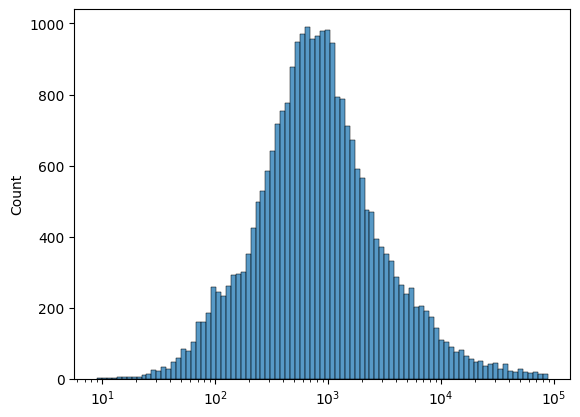

In [28]:
files = {}
for name in filenames:
    with open(f'/raid/deallab/SF_RAG_Data/T_QA/evidence/web/{name}') as f:
        files[name] = f.read()
    
file_len = [len(file.split())for file in files.values()]

sns.histplot(x=file_len, log_scale=True)

<Axes: ylabel='Count'>

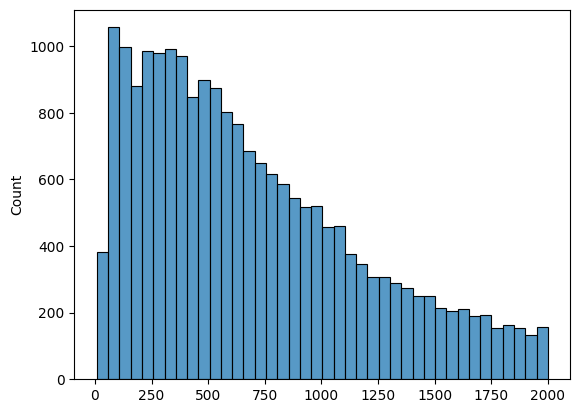

In [30]:
# remove files longer then 2000 words
clean_files = {name:file for name,file in files.items() if len(file.split())<=2000}

clean_file_len = [len(file.split())for file in clean_files.values()]

sns.histplot(x=clean_file_len)

In [35]:
# clean questions so there are only questions where one file is present
qa_pairs = []
for s in sample:
    q = qa['Question']
    a = qa['Answer']['Aliases']
    f = []
    for file in qa["SearchResults"]:
        filename = file["Filename"]
        if filename not in f and filename in clean_files:
            f.append(filename)
    if not f: continue
    qa_pairs.append({
        'question':q,
        'answer': a,
        'evidence': f
    })

len(qa_pairs)

5000

In [39]:
if not os.path.exists('/raid/deallab/SF_RAG_Data/T_QA/train_clean'):
    os.makedirs('/raid/deallab/SF_RAG_Data/T_QA/train_clean')
with open('/raid/deallab/SF_RAG_Data/T_QA/train_clean/qa_pairs.json', 'w') as f:
    json.dump(qa_pairs, f)
with open('/raid/deallab/SF_RAG_Data/T_QA/train_clean/evidence.json', 'w') as f:
    json.dump(clean_files, f)